In [28]:
from langgraph.graph import StateGraph ,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [29]:
llm = ChatOpenAI(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv('GROQ_API_KEY'),
    base_url="https://api.groq.com/openai/v1"
)

In [30]:
# define the state
class BlogState(TypedDict):
   title: str
   outline: str
   content: str
   review: str

In [31]:
def creat_outline(state: BlogState) -> BlogState:
    title=state['title']
    prompt = f"Create a detailed outline for a blog post titled '{title}'"
    outline = llm.invoke(prompt).content
    state['outline'] = outline
    return state

In [32]:
def write_content(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt=f"Write a detailed blog post on topic->{title} the following outline: {outline}"

    content = llm.invoke(prompt).content
    state['content'] = content
    return state

In [33]:
def generate_review(state: BlogState) -> BlogState:
    content = state['content']
    outline = state['outline']
    prompt=f"Review the following blog post based on {outline} how {content} can be improved and give a score out of 10 for the blog post"

    review = llm.invoke(prompt).content
    state['review'] = review
    return state

In [34]:
# define the graph
graph = StateGraph(BlogState)

# nodes 
graph.add_node("create_outline",creat_outline)
graph.add_node("write_content",write_content)
graph.add_node("generate_review",generate_review)

# edges
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","write_content")

graph.add_edge("write_content","generate_review")
graph.add_edge("generate_review",END)

workflow = graph.compile()

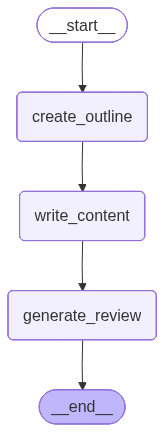

In [35]:
workflow

In [ ]:
initial_state={'title':'The ultimate goal of Cricket'}
final_state = workflow.invoke(initial_state)
print(final_state['topic'])

{'title': 'The ultimate goal of Cricket', 'outline': 'Here\'s a detailed outline for a blog post titled "The Ultimate Goal of Cricket":\n\n**I. Introduction**\n\n* Brief overview of the sport of cricket\n* Explanation of the purpose of the blog post: to explore the ultimate goal of cricket\n* Thesis statement: The ultimate goal of cricket is to score more runs than the opposing team, while also promoting sportsmanship, teamwork, and entertainment for fans.\n\n**II. The Objective of the Game**\n\n* Explanation of the basic rules of cricket: two teams, 11 players per team, batting and bowling\n* Description of the primary objective: to score runs by hitting the ball and running between wickets\n* Discussion of the importance of scoring runs in cricket: the team with the most runs at the end of the game wins\n\n**III. Strategies for Achieving the Ultimate Goal**\n\n* Explanation of various batting strategies: aggressive, defensive, and rotating strike\n* Discussion of bowling strategies: 

In [39]:
print(final_state['outline'])

Here's a detailed outline for a blog post titled "The Ultimate Goal of Cricket":

**I. Introduction**

* Brief overview of the sport of cricket
* Explanation of the purpose of the blog post: to explore the ultimate goal of cricket
* Thesis statement: The ultimate goal of cricket is to score more runs than the opposing team, while also promoting sportsmanship, teamwork, and entertainment for fans.

**II. The Objective of the Game**

* Explanation of the basic rules of cricket: two teams, 11 players per team, batting and bowling
* Description of the primary objective: to score runs by hitting the ball and running between wickets
* Discussion of the importance of scoring runs in cricket: the team with the most runs at the end of the game wins

**III. Strategies for Achieving the Ultimate Goal**

* Explanation of various batting strategies: aggressive, defensive, and rotating strike
* Discussion of bowling strategies: pace, spin, and swing
* Overview of fielding strategies: catching, throw

In [37]:
print(final_state['review'])

**Review of "The Ultimate Goal of Cricket" Blog Post**

The blog post provides a comprehensive overview of the ultimate goal of cricket, covering the objective of the game, strategies for achieving success, the role of sportsmanship, entertainment, and fan engagement. Here's a detailed review of the post:

**Strengths:**

1. **Clear structure**: The post follows a logical structure, starting with an introduction to the game, explaining the objective, strategies, and then discussing the importance of sportsmanship, entertainment, and fan engagement.
2. **Well-explained concepts**: The author provides clear explanations of cricket's basic rules, batting, bowling, and fielding strategies, making it easy for new readers to understand the game.
3. **Emphasis on sportsmanship**: The post highlights the importance of sportsmanship in cricket, which is a crucial aspect of the game.
4. **Engaging writing style**: The author's writing style is engaging, and the use of descriptive language helps 